In [1]:
from random import randint, uniform

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Vamso gerar uma base de dados de 2 mil linhas, com duas colunas idades e salários.
Idade vai variar entre 18 e 95.
Sarios vai variar entre 1300 e 100000

In [2]:
idades = [randint(18, 95) for _ in range(2000)]
salarios = [uniform(1300, 100000) for _ in range(2000)]

df = pd.DataFrame(zip(idades, salarios), columns=["idade", "salario"])

df.head()

,idade,salario
0,63,47618.830019
1,24,85502.067605
2,68,43061.803434
3,68,5090.174869
4,41,14114.098668


<Axes: xlabel='idade', ylabel='salario'>

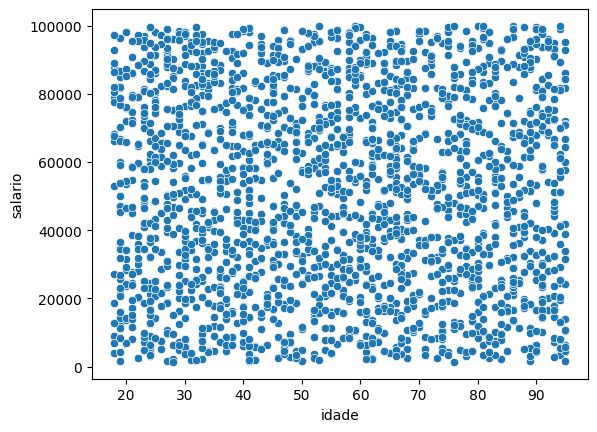

In [3]:
sns.scatterplot(x="idade", y="salario", data=df)

Text(0.5, 1.0, 'Número de pessoas por salário')

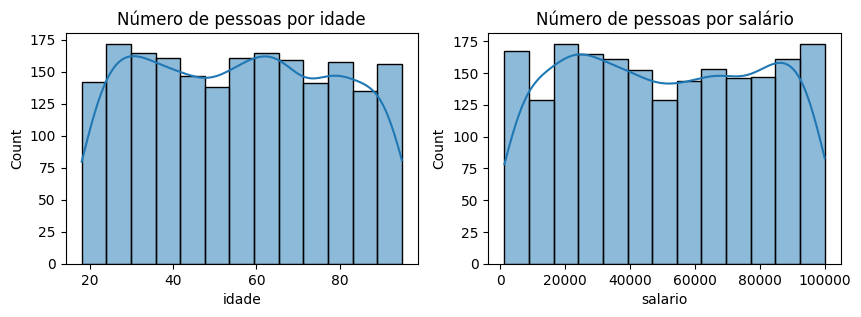

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

sns.histplot(data=df["idade"], kde=True, ax=axes[0])
axes[0].set_title('Número de pessoas por idade')

sns.histplot(data=df["salario"], kde=True, ax=axes[1])
axes[1].set_title('Número de pessoas por salário')

* Vídeo didático explicando o funcionando do kmeans:

https://youtu.be/OWyWevKhM0c?si=WqtawW-cgtNtXRQo

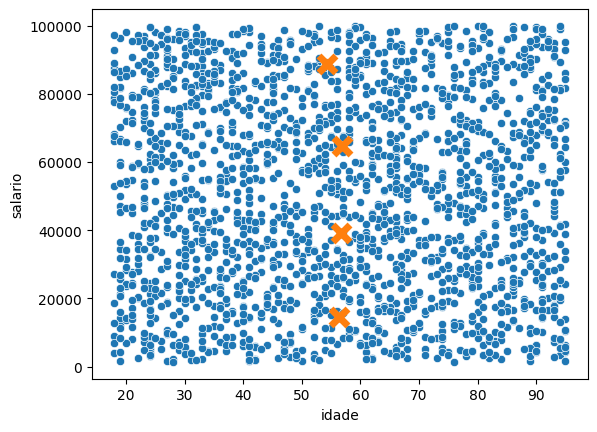

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(df[["idade", "salario"]])

centroides = kmeans.cluster_centers_

sns.scatterplot(x="idade", y="salario", data=df)
plt.scatter(centroides[:,0], centroides[:,1], marker = "x", s=150, linewidths = 5)# , zorder = 10, c=['green', 'red','blue']

In [6]:
df["cluster"] = kmeans.predict(df[["idade", "salario"]])
df.head()

,idade,salario,cluster
0,63,47618.830019,2
1,24,85502.067605,0
2,68,43061.803434,2
3,68,5090.174869,1
4,41,14114.098668,1


In [7]:
df.groupby("cluster").mean()

,idade,salario
cluster,,
0,54.340816,88718.779628
1,56.424074,14541.259732
2,56.624242,39224.455122
3,56.863158,64566.775694


## Feature Scaling

### Normalização
* Usa como "escalonador" o valor mínimo e o valor máximo
* Varia entre 0 e 1
* "Achata" os dados, ou seja, outliers perdem seu poder de influência
* São indicados para os casos onde se tem distribuições normais nos dados;

### Padronização
* Usa como "escalonador" o valor da média e o desvio padrão
* Pode ter valores negativos
* Consegue representar mais a variabilidade dos dados
* São indicados para os casos onde não se tem distribuições normais nos dados;



## Como saber se os dados seguem uma distribuição normal?

1) Gráficos

2) Teste de normalidade

* **Hipotese nula**: Os dados seguem distribuição normal
* **Hipotese alternativa**: Os dados não seguem distribuição normal


**k2 (chi-squared statistic)**:

Este valor é, na verdade, a soma de dois termos elevados ao quadrado: s² + k². Sendo s o valor z obtido através do teste de assimetria (skewtest) e k é o valor da estatística z obtido pelo teste de curtose.

**p (p-value)**:

É a probabilidade de se obter um efeito tão extremo quanto o que está ocorrendo em nossos dados, assumindo que a hipótese nula é verdadeira. (Qual a probabilidade da distribuição que observamos naquele histograma ocorrer? Este é o p-valor)

**alpha**:


Qual o nível de erro que aceitamos em nosso teste? Rejeitamos a hipótese nula quando o valor-p for menor do que o nível de significância do nosso teste

In [8]:
from scipy.stats import normaltest

k2, p = normaltest(df['salario'])

alpha = 0.05 # 5% Se a probabilidade for menor que 5% então vamos rejeitar a hipótese nula

print(k2, p)

# Se o p-valor for menor que o nível de significância, temos evidências de que essa hipótese nula pode ser rejeitada
if p < alpha:
    print("A Hipótese nula pode ser rejeitada")
else:
    print("A hipótese nula não pode ser rejeitada")

2412.6843890477817 0.0
A Hipótese nula pode ser rejeitada


In [9]:
from scipy.stats import normaltest

k2, p = normaltest(df['idade'])

alpha = 0.05

print(k2, p)

# Se o p-valor for menor que o nível de significância, temos evidências de que essa hipótese nula pode ser rejeitada
if p < alpha:
    print("A Hipótese nula pode ser rejeitada")
else:
    print("A hipótese nula não pode ser rejeitada")

1554.00979637654 0.0
A Hipótese nula pode ser rejeitada


In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler() #chamando o metodo de padronização dos dados (média e std)

dados_input = df[["idade", "salario"]]
scaler.fit(dados_input)

dados_input_scaled = scaler.transform(dados_input)

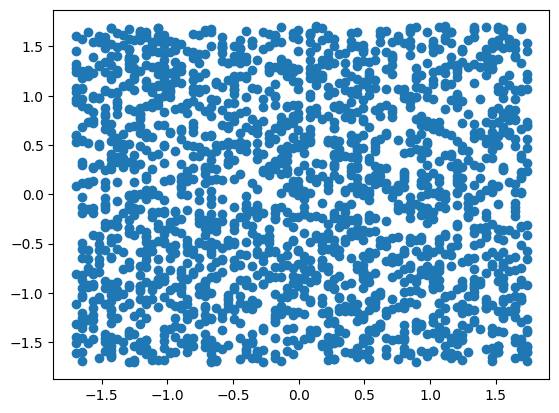

In [11]:
plt.scatter(x=dados_input_scaled[:,0], y=dados_input_scaled[:,1])

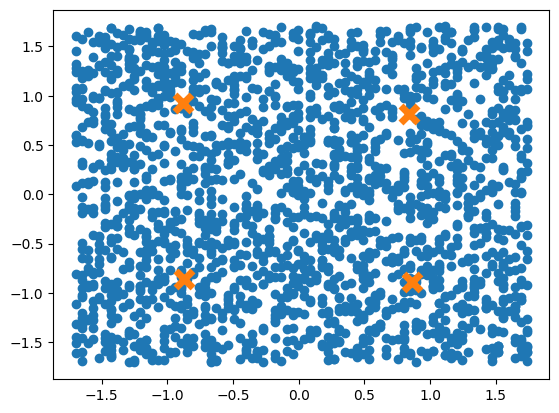

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(dados_input_scaled)

centroides = kmeans.cluster_centers_

plt.scatter(x=dados_input_scaled[:,0], y=dados_input_scaled[:,1])
plt.scatter(centroides[:,0], centroides[:,1], marker = "x", s=150, linewidths = 5)# , zorder = 10, c=['green', 'red','blue']

In [13]:
df["cluster"] = kmeans.predict(dados_input_scaled)
df.groupby("cluster").mean()

,idade,salario
cluster,,
0,74.935673,74391.155651
1,36.572854,25933.837268
2,36.320329,77557.018172
3,75.515030,25018.081850


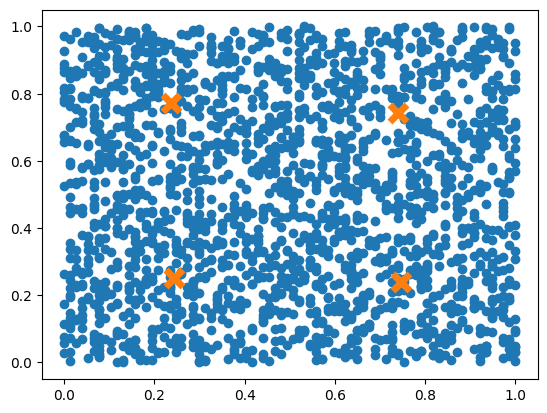

In [14]:
scaler = MinMaxScaler()

dados_input = df[["idade", "salario"]]
scaler.fit(dados_input)

dados_input_scaled = scaler.transform(dados_input)

kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(dados_input_scaled)

centroides = kmeans.cluster_centers_

plt.scatter(x=dados_input_scaled[:,0], y=dados_input_scaled[:,1])
plt.scatter(centroides[:,0], centroides[:,1], marker = "x", s=150, linewidths = 5)# , zorder = 10, c=['green', 'red','blue']

In [15]:
df["cluster"] = kmeans.predict(dados_input_scaled)

df.head()

,idade,salario,cluster
0,63,47618.830019,3
1,24,85502.067605,2
2,68,43061.803434,3
3,68,5090.174869,3
4,41,14114.098668,1


In [16]:
df.groupby("cluster").mean()

,idade,salario
cluster,,
0,74.935673,74391.155651
1,36.620278,25980.736929
2,36.310700,77610.023096
3,75.554217,25020.805751


# Pontos importantes

* Feature scaling é importante para algoritmos que utilizam distância e redes neurais;
* A avaliação do resultado de uma clusterização é feita analisando a distribuição dos dados nos grupos

## Comprovando os resultados do teste de normalidade

(array([ 16.,  48., 138., 331., 447., 451., 321., 182.,  55.,  11.]),
 array([-3.01880245, -2.42067943, -1.82255642, -1.2244334 , -0.62631039,
        -0.02818737,  0.56993564,  1.16805866,  1.76618168,  2.36430469,
         2.96242771]),
 <BarContainer object of 10 artists>)

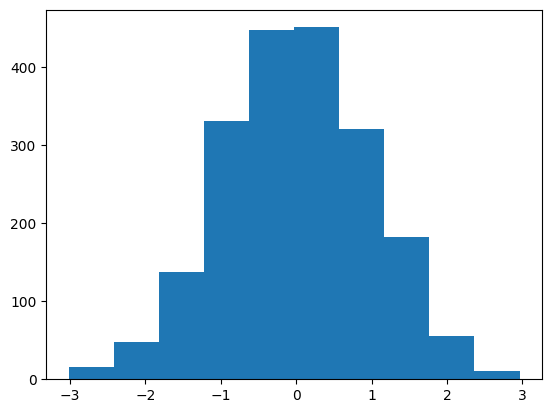

In [17]:
from random import gauss

sigma = 1
media = 0

valores_normais = [gauss(media, sigma) for i in range(0, 2000)]
plt.hist(valores_normais)

In [18]:
from scipy.stats import normaltest

k2, p = normaltest(valores_normais)

alpha = 0.05

print(k2, p)

# Se o p-valor for menor que o nível de significância, temos evidências de que essa hipótese nula pode ser rejeitada
if p < alpha:
    print("A Hipótese nula pode ser rejeitada")
else:
    print("A hipótese nula não pode ser rejeitada")

1.7976810834872747 0.40704133367965245
A hipótese nula não pode ser rejeitada
